# Notebook angle estimation machine learning part
This notebook contains the code that is used to train the model for predicting the best angle at which the angiography should be taken 

In [1]:
import pandas as pd
import torch 
import numpy as np
import torch.nn as nn
from torchsummary import summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from datetime import datetime
import neptune
import model as mf

from torchvision.io import read_image
from torchvision.transforms.functional import to_tensor


DATA_PATH = "dataset/" #Do not change folder structure that was created by Kasper
# dataset/
#   DRR_images/
#       [n].png
#   excel/
#       *.xlsx 


In [2]:
run = neptune.init_run(
     name= "Try 2",
     description= "Experiment with new data",
     project="undefined1234/Team-Challenge",
     api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJlZTZlZjc1Mi00YTFlLTQ1YjUtYjBiNC02OGRkZTY4ZDAwMTgifQ==",
)  # your credentials

params = {

    "learning_rate": 0.001,
    "momentum": 0.9,
    "optimizer": "SGD"
}
run["parameters"] = params

[neptune] [warning] NeptuneWarning: By default, these monitoring options are disabled in interactive sessions: 'capture_stdout', 'capture_stderr', 'capture_traceback', 'capture_hardware_metrics'. You can set them to 'True' when initializing the run and the monitoring will continue until you call run.stop() or the kernel stops. NOTE: To track the source files, pass their paths to the 'source_code' argument. For help, see: https://docs.neptune.ai/logging/source_code/


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/undefined1234/Team-Challenge/e/TEAM-5


In [3]:
torch.__version__

'2.6.0+cu126'

In [4]:
torch.cuda.is_available()

True

## Loading labels

In [3]:
labels = pd.read_excel(DATA_PATH+"excel/all_DRR_scores.xlsx")
labels['fullpath'] = DATA_PATH+"DRR_images/"+labels['DRR filename']+".png"
labels['score_classified'] = pd.qcut(labels['score'], 5).factorize()[0]

#labels.iloc[0]['fullpath']
labels

,DRR filename,aneurysm score,neck score,score,fullpath,score_classified
0,C0001_X0_Y0,12.272727,1.783784,14.056511,dataset/DRR_images/C0001_X0_Y0.png,0
1,C0001_X10_Y0,7.358974,1.584906,8.943880,dataset/DRR_images/C0001_X10_Y0.png,1
2,C0001_X20_Y0,5.538462,1.921569,7.460030,dataset/DRR_images/C0001_X20_Y0.png,1
3,C0001_X30_Y0,5.309091,2.074074,7.383165,dataset/DRR_images/C0001_X30_Y0.png,1
4,C0001_X40_Y0,4.949153,1.689189,6.638342,dataset/DRR_images/C0001_X40_Y0.png,2
...,...,...,...,...,...,...
6835,C0074_X310_Y180,2.008721,2.130435,4.139156,dataset/DRR_images/C0074_X310_Y180.png,3
6836,C0074_X320_Y180,1.817175,1.709091,3.526265,dataset/DRR_images/C0074_X320_Y180.png,4
6837,C0074_X330_Y180,1.527578,2.289474,3.817052,dataset/DRR_images/C0074_X330_Y180.png,4
6838,C0074_X340_Y180,3.066038,2.050000,5.116038,dataset/DRR_images/C0074_X340_Y180.png,3


### DataLoader

In [4]:
train, val = train_test_split(labels)

train_dataloader = torch.utils.data.DataLoader(mf.CustomImageDataset(train), batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mf.CustomImageDataset(val), batch_size=64, shuffle=True)


Feature batch shape: torch.Size([64, 1, 256, 256])
Feature batch type: torch.FloatTensor
Labels batch shape: torch.Size([64])


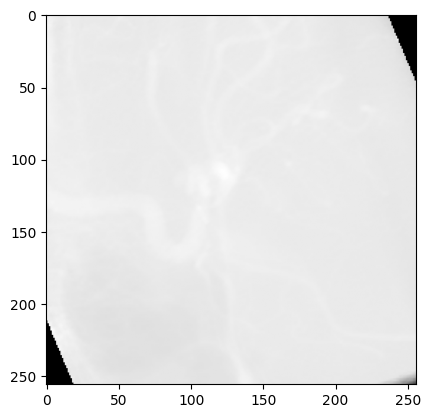

Label: 1


In [29]:
train, label = next(iter(train_dataloader))
print(f"Feature batch shape: {train.size()}")
print(f"Feature batch type: {train.type()}")
print(f"Labels batch shape: {label.size()}")
img = train[31].squeeze()
label = label[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

### Model

In [30]:
device = torch.device("cuda")
model = mf.Block().to(device)

summary(model, torch.Size([1,256,256]), 64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [64, 4, 256, 256]              40
       BatchNorm2d-2          [64, 4, 256, 256]               8
         MaxPool2d-3          [64, 4, 128, 128]               0
            Conv2d-4         [64, 16, 128, 128]             592
       BatchNorm2d-5         [64, 16, 128, 128]              32
         MaxPool2d-6           [64, 16, 64, 64]               0
           Flatten-7                [64, 65536]               0
            Linear-8                   [64, 64]       4,194,368
              ReLU-9                   [64, 64]               0
           Linear-10                    [64, 5]             325
Total params: 4,195,365
Trainable params: 4,195,365
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 16.00
Forward/backward pass size (MB): 608.06
Params size (MB): 16.00
Est

In [31]:
output = model(train.to(device))
output

tensor([[ 0.1379,  0.1641, -0.1604, -0.1258,  0.1373],
        [ 0.1825,  0.0008, -0.0852, -0.0239,  0.0662],
        [ 0.5101,  0.4472, -0.1752,  0.2963, -0.1861],
        [ 0.1831,  0.1504,  0.0522, -0.0149,  0.1492],
        [ 0.3207,  0.1925, -0.2628, -0.1087,  0.1144],
        [ 0.2633,  0.1313, -0.0254, -0.0375,  0.0773],
        [ 0.2978,  0.1946, -0.0813, -0.0707,  0.1275],
        [ 0.4094,  0.0245, -0.1776, -0.1014, -0.0438],
        [ 0.3177, -0.0798, -0.2590, -0.0692, -0.0426],
        [ 0.3387,  0.1719, -0.1227, -0.1511,  0.2147],
        [ 0.1994, -0.0069, -0.1435, -0.0355,  0.0927],
        [ 0.3940,  0.0831, -0.0233, -0.0938, -0.0840],
        [ 0.0450, -0.1484, -0.2190, -0.0759,  0.1397],
        [ 0.3308,  0.0752, -0.0767, -0.1049,  0.0539],
        [ 0.2545,  0.1417,  0.0513, -0.0436,  0.0417],
        [ 0.4752,  0.1556, -0.0320, -0.2647,  0.0462],
        [ 0.0882, -0.3452, -0.4393, -0.0677,  0.2468],
        [ 0.2894, -0.0414, -0.1398, -0.0371, -0.0333],
        [ 

### Loss function

In [32]:
loss_fn = nn.CrossEntropyLoss()
loss_fn.to(device=device)

CrossEntropyLoss()

### Optimizer

In [33]:
optimizer = torch.optim.SGD(model.parameters(), lr=params["learning_rate"], momentum=params["momentum"])


### Training

In [34]:
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    # Here, we use enumerate(training_loader) instead of
    # iter(training_loader) so that we can track the batch
    # index and do some intra-epoch reporting
    for i, data in enumerate(train_dataloader):
        # Every data instance is an input + label pair
        inputs, labels = data
        

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        outputs = model(inputs.to(device))

        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels.to(device))
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(train_dataloader) + i + 1
            running_loss = 0.

    return last_loss

In [35]:
# Initializing in a separate cell so we can easily add more epochs to the same run
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
#writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0






EPOCHS = 100

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(epoch_number)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_dataloader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device))
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
    run["train/loss"].append(avg_loss)
    run["val/loss"].append(avg_vloss)



    # Track best performance, and save the model's state
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1
model.train(False)
run.stop()

EPOCH 1:
  batch 10 loss: 1.618420159816742
  batch 20 loss: 1.6217893481254577
  batch 30 loss: 1.5765130043029785
  batch 40 loss: 1.585866129398346
  batch 50 loss: 1.6128992199897767
  batch 60 loss: 1.574342679977417
  batch 70 loss: 1.597635805606842
  batch 80 loss: 1.5894829392433167
LOSS train 1.5894829392433167 valid 1.5917198657989502
EPOCH 2:
  batch 10 loss: 1.595240044593811
  batch 20 loss: 1.5808349609375
  batch 30 loss: 1.5762701749801635
  batch 40 loss: 1.5522668480873107
  batch 50 loss: 1.5516389966011048
  batch 60 loss: 1.5813712000846862
  batch 70 loss: 1.5768203377723693
  batch 80 loss: 1.5710531234741212
LOSS train 1.5710531234741212 valid 1.5725926160812378
EPOCH 3:
  batch 10 loss: 1.5815056324005128
  batch 20 loss: 1.545893657207489
  batch 30 loss: 1.5674960255622863
  batch 40 loss: 1.5619240641593932
  batch 50 loss: 1.5570800185203553
  batch 60 loss: 1.56306734085083
  batch 70 loss: 1.566342043876648
  batch 80 loss: 1.5492914080619813
LOSS train 

In [36]:
torch.save(model.state_dict(), "mymodel_classified.pth")

In [37]:
torch.cuda.empty_cache()
del model
del loss_fn

print(torch.cuda.memory_allocated())
print(torch.cuda.memory_reserved())

453299200
480247808
